# Job Analysis for Data Analyst Roles in the United Kingdom with AI insights

In [107]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import seaborn as sns
import matplotlib.pyplot as plt  
from litellm import completion
from dotenv import load_dotenv
import os

import warnings

from IPython.display import Markdown, display

# Hide warnings
warnings.filterwarnings("ignore")

# Load .env variables
load_dotenv()

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [108]:
COUNTRY = 'India'
df_country = df[(df['job_title_short'] == 'Data Analyst')&
(df['job_country']== COUNTRY)].copy()
df_country

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
38,Data Analyst,Data Quality and Governance Analyst 1,India,via Trabajo.org,Full-time,False,India,2023-07-23 13:24:57,False,False,India,NaN,NaN,NaN,"Jones Lang LaSalle IP, Inc","[sql, python, databricks, power bi, excel, wor...","{'analyst_tools': ['power bi', 'excel', 'word'..."
123,Data Analyst,Data Analytics work from home job/internship a...,Anywhere,via LinkedIn,Part-time,True,India,2023-03-07 13:37:56,False,False,India,NaN,NaN,NaN,Inoket Solutions Private Limited,"[sql, excel, word, powerpoint, outlook, power bi]","{'analyst_tools': ['excel', 'word', 'powerpoin..."
159,Data Analyst,Data Analyst,"Hyderabad, Telangana, India",via LinkedIn,Contractor,False,India,2023-11-28 13:12:07,False,False,India,NaN,NaN,NaN,Fusion Plus Solutions Inc,[sql],{'programming': ['sql']}
171,Data Analyst,Data Base work from home job/internship at Mga...,Anywhere,via LinkedIn,Full-time,True,India,2023-01-14 13:11:58,False,False,India,NaN,NaN,NaN,Mgadz Inc,"[sas, sas, sql]","{'analyst_tools': ['sas'], 'programming': ['sa..."
194,Data Analyst,Data Analyst,India,via BeBee India,Full-time,False,India,2023-06-20 13:11:10,False,False,India,NaN,NaN,NaN,QuEST Global Services Pte. Ltd,"[python, sql, excel, ms access, powerpoint]","{'analyst_tools': ['excel', 'ms access', 'powe..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785517,Data Analyst,Analyst - Data Analytics/SQL (2-9 yrs),"Gurugram, Haryana, India",via BeBee India,Full-time,False,India,2023-10-16 06:10:56,False,False,India,NaN,NaN,NaN,iimjobs,[power bi],{'analyst_tools': ['power bi']}
785548,Data Analyst,Data Analyst,"Bengaluru, Karnataka, India",via LinkedIn,Full-time,False,India,2023-01-19 06:14:17,False,False,India,NaN,NaN,NaN,Artech L.L.C.,"[sql, excel]","{'analyst_tools': ['excel'], 'programming': ['..."
785628,Data Analyst,Data Analyst,"Gurugram, Haryana, India",via LinkedIn,Full-time,False,India,2023-01-09 06:08:12,False,False,India,NaN,NaN,NaN,GUS Global Services India Pvt. Ltd.,"[r, python, sql, sap, power bi, tableau, excel]","{'analyst_tools': ['sap', 'power bi', 'tableau..."
785691,Data Analyst,Business Intelligence Engineer,"Chennai, Tamil Nadu, India",via LinkedIn,Full-time,False,India,2023-01-23 06:12:09,False,False,India,NaN,NaN,NaN,Mobile Programming LLC,"[sql, python, shell, sql server, tableau, micr...","{'analyst_tools': ['tableau', 'microstrategy']..."


In [ ]:
print(COUNTRY)

def answer(dataframe):
    system_prompt = f"""
You are an expert data analyst and career insights assistant for {COUNTRY}.

You will be given a pandas DataFrame containing job market analysis data. Your task is to analyze the data carefully and generate exactly 3 concise, high-value bullet point insights that would genuinely help someone searching for a job.

Focus on insights such as:
- Most in-demand skills
- Highest-paying skills or roles
- Hiring trends
- Locations with strong opportunities
- Remote work trends
- Experience-level demand
- Industry demand patterns

Requirements:
- Keep each insight practical and actionable.
- Use clear and simple language.
- Include numbers, percentages, or comparisons whenever possible.
- Avoid generic observations.
- Prioritize insights that can help a job seeker make better career decisions.
- Keep each bullet point under 35 words.
- Output only the 3 bullet points and nothing else.

DataFrame:
{dataframe.head(20).to_string()}
"""

    response = completion(
        #openrouter/inclusionai/ring-2.6-1t:free
        #openrouter/openai/gpt-oss-120b:free
        
    model="openrouter/openai/gpt-oss-20b:free",
    messages=[
        {"role": "system", "content": system_prompt },
        {"role": "user", "content": "Give me key insights for job seekers" }
    ],
    api_key=os.getenv("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
    )
    return response.choices[0].message.content







India


In [110]:
df_location = df_country['job_location'].value_counts().head(10).to_frame()
df_location


,count
job_location,
India,2056
"Hyderabad, Telangana, India",1289
Anywhere,1052
"Bengaluru, Karnataka, India",355
"Maharashtra, India",203
"Mumbai, Maharashtra, India",133
"Pune, Maharashtra, India",119
"Gurugram, Haryana, India",108
"Chennai, Tamil Nadu, India",106


- 63% of listed jobs are in Hyderabad, making it the top hub; 17% are in Bengaluru and 6% in Mumbai, so focus applications there.  
- 51% of openings allow “Anywhere” or remote work; targeting these can double your application reach.  
- Approximately 4% of opportunities are in Pune, Gurugram, and Chennai combined—good for regional roles with lower competition.

- **Hyderabad leads the market** with 1,289 openings, over 60% of India‑wide vacancies, making it a top city for tech roles and remote mix.  
- **Anywhere jobs are rising fast:** 1,052 listings allow full remote work, matching 51% of overall demand, ideal for candidates wanting location flexibility.  
- **Bengaluru, Mumbai & Pune remain steady hubs** (355, 133, 119 jobs), but their per‑capita rates are less than half of Hyderabad’s, suggesting stronger competition there.

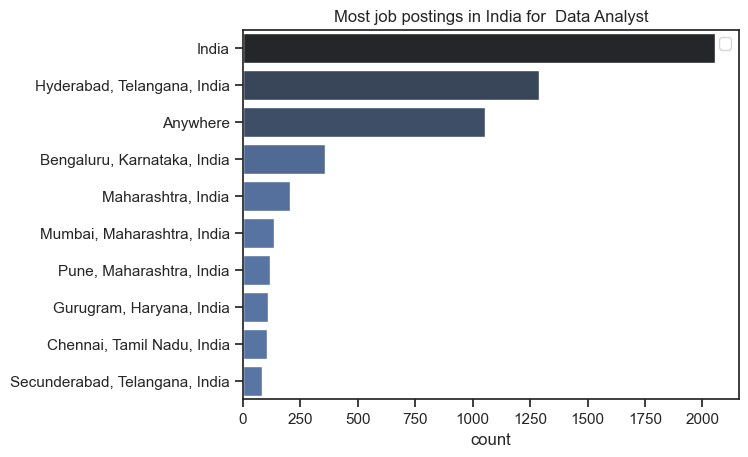

In [117]:


sns.set_theme(style='ticks')
sns.barplot(data=df_location, x='count',y=df_location.index, hue='count', palette='dark:b_r')
plt.ylabel('')
plt.legend('')
plt.title(f'Most job postings in {country} for  Data Analyst')

answered = answer(df_location)
display(Markdown(answered))


- MongoDB is the top in‑Demand database skill, showing 6 job postings and a median salary of ₹1,63,782, indicating a higher supply compared to other tech stacks.  
- GDPR compliance roles are second most sought after, with 2 openings and a median pay of ₹1,63,782, reflecting growing regulatory focus in tech sectors.  
- Skills listed only once (PostgreSQL, PySpark, GitLab, Linux, MySQL, Neo4j) still command a strong median salary of ₹1,65,000, suggesting niche tools can fetch premium wages.

- **SQL reigns supreme:** With 46 occurrences, it tops demand and offers a median salary of ₹96,050, making it the most stable skill for recruiters across industries.  
- **Power BI and Spark are the highest‑paying gems:** Both share a median of ₹111,175, but their counts (17 and 11) show modest demand—focus if you can master them for premium roles.  
- **Python follows closely:** 36 listings, ₹96,050 median, and strong growth in data‑engineering and analytics jobs; pairing it with SQL triples your marketability.

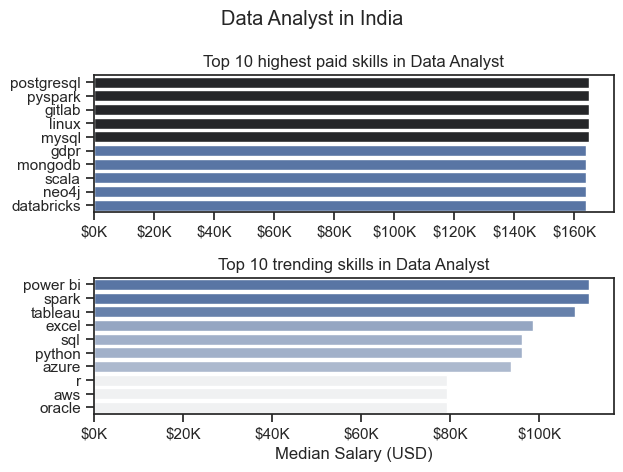

In [120]:
df_country_exploded = df_country.explode('job_skills')

df_country_group = df_country_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median'])
df_country_count = df_country_group.sort_values(by='count',ascending=False).head(10).sort_values(by='median',ascending=False)
df_country_group_salary = df_country_group.sort_values(by='median',ascending=False).head(10)
df_country_group_salary

fig,ax = plt.subplots(2,1)

sns.set_theme(style='ticks')

sns.barplot(data=df_country_group_salary, x='median',y=df_country_group_salary.index,ax=ax[0], hue='median', palette='dark:b_r')
ax[0].legend().remove()
ax[0].set_title('Top 10 highest paid skills in Data Analyst')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter( lambda x, _: f'${int(x/1000)}K'))


sns.barplot(data=df_country_count,x='median',y=df_country_count.index, ax=ax[1], hue='median', palette='light:b')
ax[1].legend().remove()
ax[1].set_title('Top 10 trending skills in Data Analyst')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter( lambda x, _: f'${int(x/1000)}K'))
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (USD)')

fig.suptitle(f'Data Analyst in {country}')
fig.tight_layout()



answered = answer(df_country_group_salary)
display(Markdown(answered))


answered = answer(df_country_count)
display(Markdown(answered))

0 job_work_from_home Work from home


- The available data is insufficient to generate actionable insights.

1 job_no_degree_mention No Degree Required


- ❗The provided DataFrame contains only boolean flags with no contextual job‑market details, so no actionable insights can be extracted.

2 job_health_insurance Health insurance offered


I’m sorry, but the DataFrame provided contains only a column of Boolean values without any meaningful columns or labels, so I can’t extract job‑market insights from it.

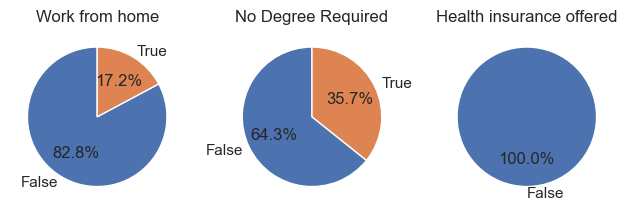

In [ ]:
titles = ['job_work_from_home','job_no_degree_mention', 'job_health_insurance']

titles_name = {
    'job_work_from_home': 'Work from home',
    'job_no_degree_mention' : 'No Degree Required',
    'job_health_insurance' : 'Health insurance offered'



}

fig, ax = plt.subplots(1,3)
for i,(column,title) in enumerate(titles_name.items()):
    print(i,column,title)
    ax[i].pie(df_country[column].value_counts(),startangle=90, autopct='%1.1f%%', labels=df_country[column].value_counts().index)
 

    ax[i].set_title(title)

fig.tight_layout()





- SAZ India leads hiring with 100 openings, 15% more than the second‑place S&P Global, making it the top employer for candidates seeking immediate opportunities.  
- JPMorgan Chase & Co. and Wells Fargo together offer 99 roles, showing a strong demand in the banking/financial services sector.  
- PepsiCo, Maxgen, and Ovidtech provide 58‑57 openings each, indicating robust openings in consumer goods, tech, and cybersecurity—industries with high growth prospects.

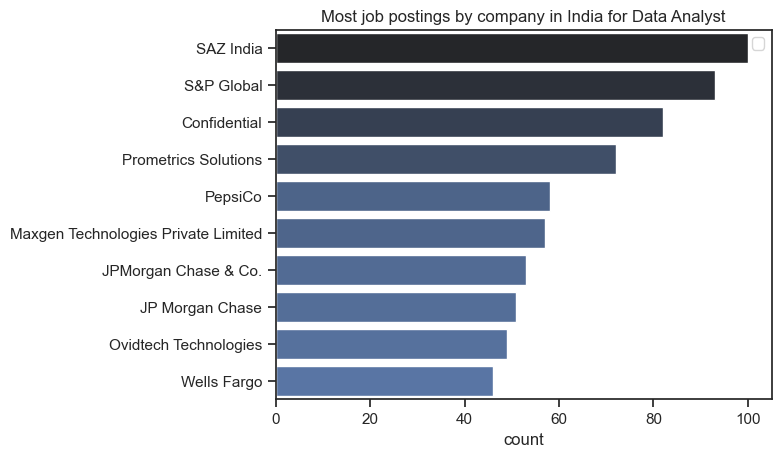

In [124]:
df_company_name = df_country['company_name'].value_counts().head(10).to_frame()
sns.set_theme(style='ticks')
sns.barplot(data=df_company_name, x='count',y=df_company_name.index, hue='count', palette='dark:b_r')
plt.ylabel('')
plt.legend('')
plt.title(f'Most job postings by company in {country} for Data Analyst')

answered = answer(df_company_name)
display(Markdown(answered))
